In [1]:
import math
import time
import random
import numpy as np
import json
from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp
from bessel_zeros import get_bessel_zeros
from scipy.special import jv, jvp, gamma, loggamma
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import matplotlib.patches as patches
font = font_manager.FontProperties(style='normal', size=20)
import matplotlib.ticker as ticker
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

from bessel_zeros import get_bessel_zeros
from CDFs import build_cdfs as build_cdfs
import seaborn as sns

In [9]:
# from pathlib import Path
import os
# path = Path.cwd()
path = os.getcwd() #'/Users/arashfahim/Documents/GitHub/Power_Series_Stochastic_Modeling/Tests'

print(os.getcwd())

/Users/arashfahim/Documents/GitHub/Power_Series_Stochastic_Modeling/Tests


In [10]:
def avg_length(d):
        path_length_woc = path + f"/outputs/d{d}/path_length_WoC_{d}.json"
        with open(path_length_woc, 'r') as json_file:
                # Use json.load() to convert the file content into a Python dictionary
                length_dict_woc = json.load(json_file)
        path_p_exit = path + f"/outputs/d{d}/p_exit_{d}.json"
        with open(path_p_exit, 'r') as json_file:
                # Use json.load() to convert the file content into a Python dictionary
                p_dict = json.load(json_file)       
        path_length_wohb = path + f"/outputs/d{d}/path_length_WoHB_{d}.json"          
        with open(path_length_wohb, 'r') as json_file:
                # Use json.load() to convert the file content into a Python dictionary
                length_dict_wohb = json.load(json_file)    
                # p_surv = [v for k, v in p_dict.items()]
        avg_length_woc = np.array([[p_dict[s], np.mean(length)] for s, length in length_dict_woc.items()])
        avg_length_wohb = np.mean(length_dict_wohb['wohb'])
        return avg_length_woc.astype(float), avg_length_wohb, p_dict

In [11]:
avg_woc = {}
avg_wohb = {}
p_dict = {}
dims = [2,10,50,100]
for i,d in enumerate(dims):
    tmp = avg_length(d)
    avg_woc[d] = tmp[0]
    avg_wohb[d] = tmp[1]
    p_dict[d] = tmp[2]
    
vals = [v for k,v in avg_wohb.items()]
p_dict

{2: {'0.005': 9.43689570931383e-15,
  '0.13': 0.04043932263568617,
  '0.255': 0.2554689038177044,
  '0.38': 0.46936858093241096,
  '0.505': 0.6285430885287833,
  '0.63': 0.7409528825753232,
  '0.755': 0.819491106039675,
  '0.88': 0.8742396923933475,
  '1.0050000000000001': 0.9123861873101011,
  '1.1300000000000001': 0.9389623014680308,
  '1.2550000000000001': 0.9574770888425037,
  '1.3800000000000001': 0.9703757289923222},
 10: {'0.005': 2.9058977446538847e-12,
  '0.015': 3.6369762757004764e-10,
  '0.025': 3.0289381066528343e-05,
  '0.035': 0.00249957433813619,
  '0.045': 0.02295665480479414,
  '0.055': 0.08167692397698167,
  '0.065': 0.17916261591182825,
  '0.075': 0.29889705606492034,
  '0.085': 0.42226991946075565,
  '0.095': 0.5364520118566389,
  '0.105': 0.6351678371739453,
  '0.115': 0.7167952086707358,
  '0.125': 0.7823118498162022,
  '0.135': 0.8338421711055136,
  '0.145': 0.8738086855479023,
  '0.155': 0.9045051653204358,
  '0.165': 0.9279202880137547,
  '0.17500000000000002':

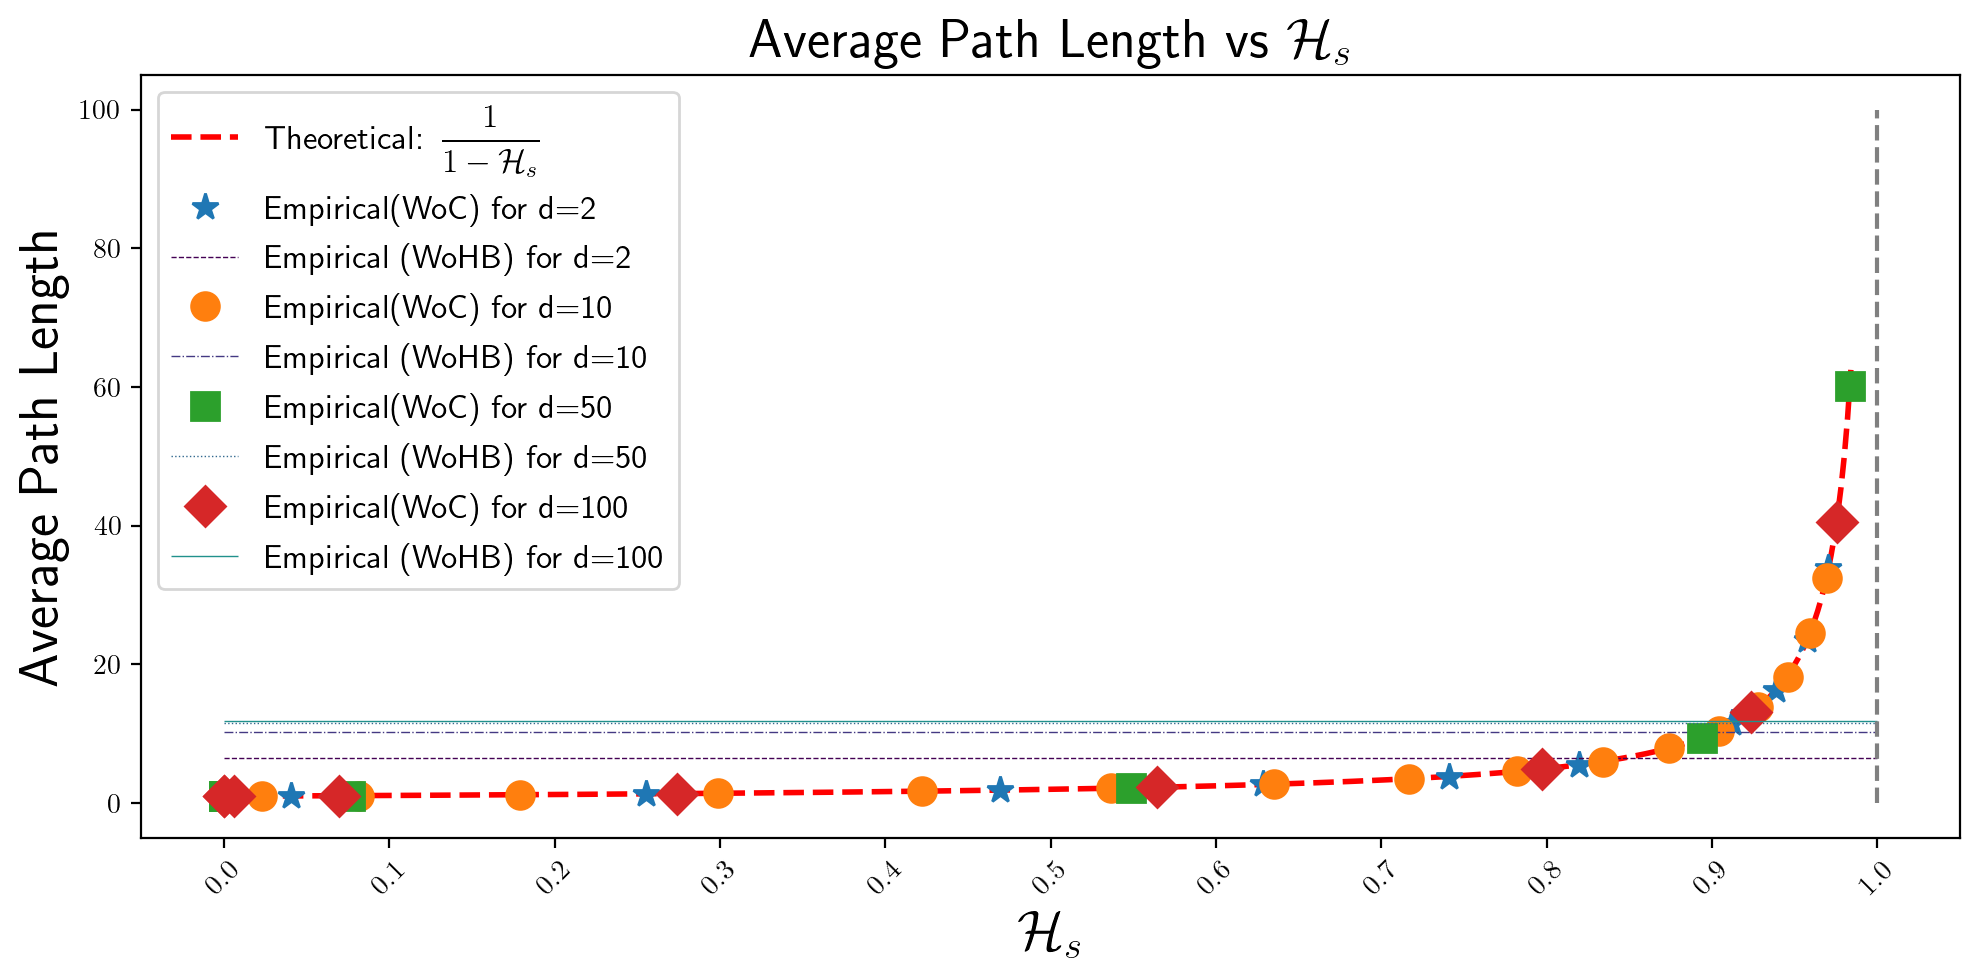

In [12]:
# ── PLOTTING ────────────────────────────────────────────────────────────────
f , ax = plt.subplots(1,1,figsize=(10, 5),dpi=200)
r = np.arange(0.,0.986,0.002)
colors = plt.cm.viridis(np.linspace(0, 0.5, len(dims)))
marks = ['*', 'o', 's', 'D']
linestyles = ['--', '-.', ':', '-']
ax.plot(r, (1/(1-np.array(r))), linewidth=2, linestyle='--', color='red', label=r'Theoretical: $\dfrac{1}{1-\mathcal{H}_s}$')
for d in dims:
    ax.plot(avg_woc[d][:,0], avg_woc[d][:,1],  marker=marks[dims.index(d)], markersize=10, linewidth=0, label=f'Empirical(WoC) for d={d}')
    ax.hlines(vals[dims.index(d)], xmin=0, xmax=1, linewidth=.5, linestyles=linestyles[dims.index(d)], color = colors[dims.index(d)], label=f'Empirical (WoHB) for d={d}')


plt.xlabel(r'$\mathcal{{H}}_s$', fontproperties=font)
plt.ylabel('Average Path Length', fontproperties=font)
plt.title(r'Average Path Length vs $\mathcal{{H}}_s$', fontproperties=font)
ax.set_xticks(np.arange(0.,1.1,0.1))
plt.vlines(1,ymin=0,ymax=100, colors='grey', linestyles='dashed')
plt.xticks(rotation=45);
# # plt.yscale('log');
# # plt.xscale('log');
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(prop={'size': 'large'}, loc='upper left', bbox_to_anchor=(0, 1))
plt.tight_layout();
# plt.show()
f.savefig(f'avg_path_length_vs_dim.pdf',format="pdf",dpi=600)

In [13]:
H_s = {}
for i,d in enumerate(dims):    
    H_s[d] = np.array([[float(s),float(h)] for s, h in p_dict[d].items()])

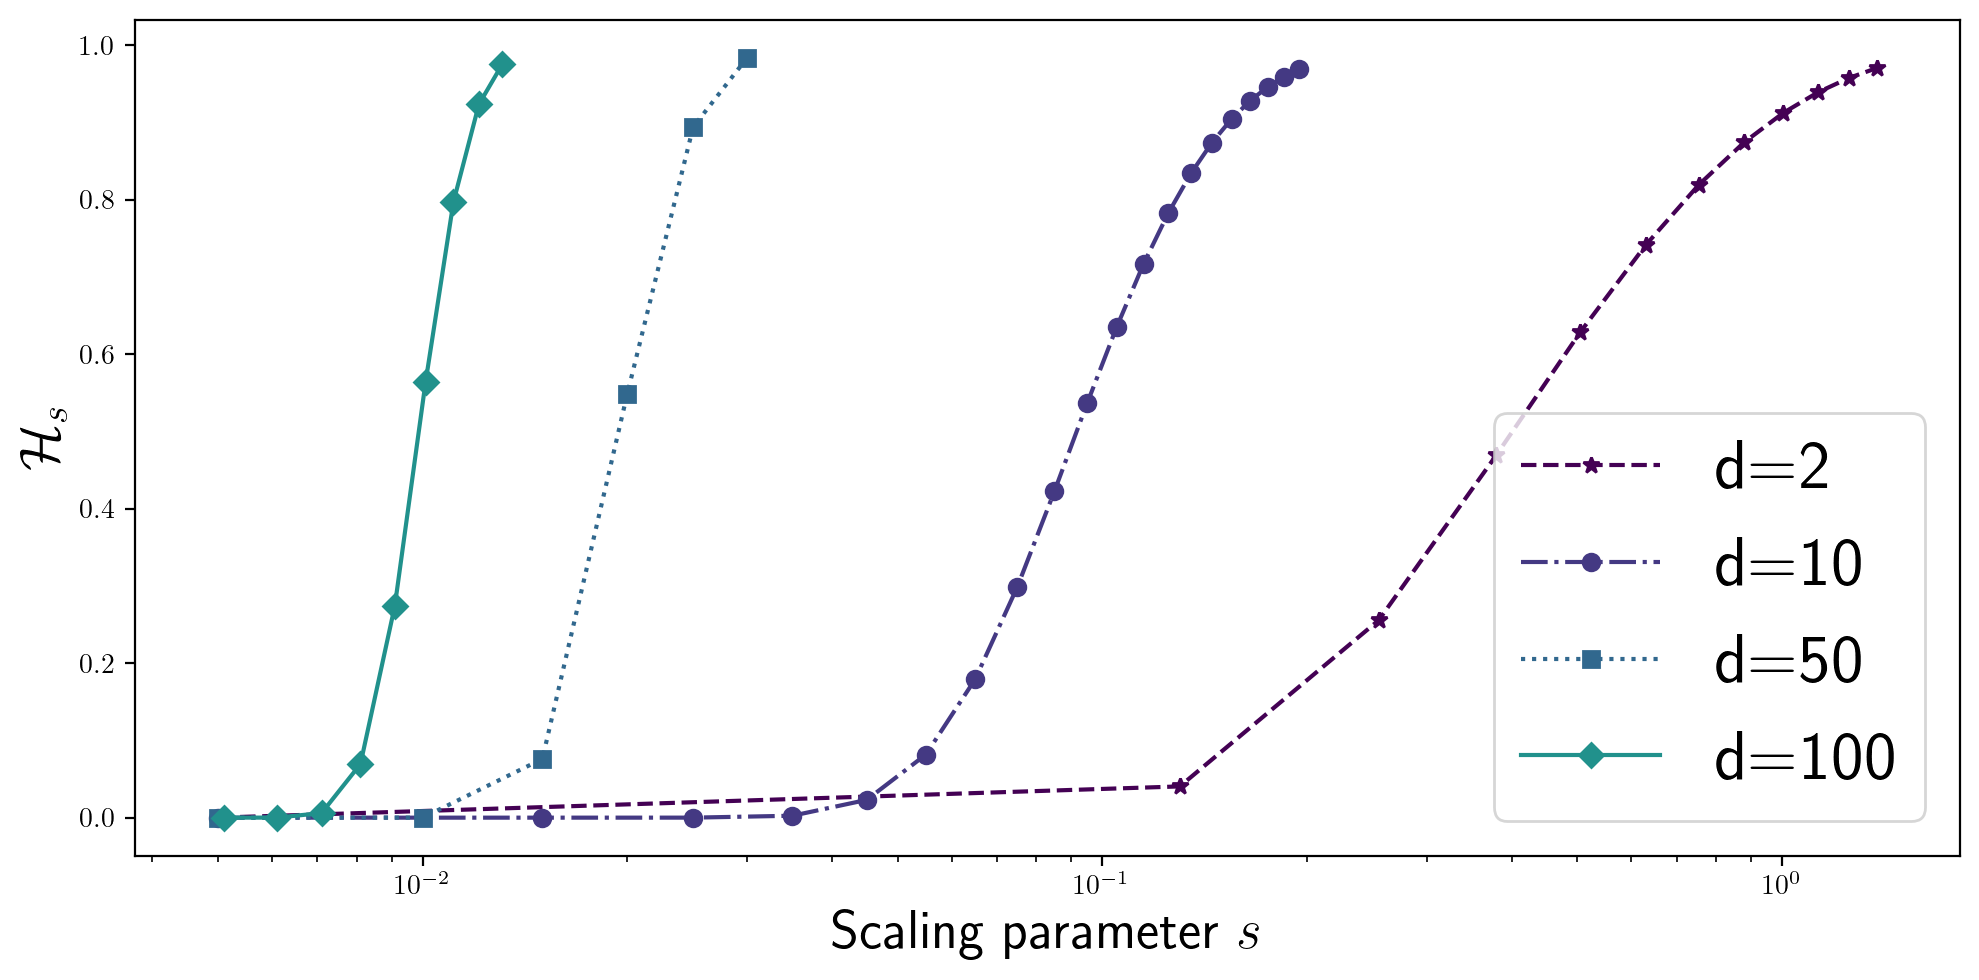

In [14]:
f , ax = plt.subplots(figsize=(10, 5),dpi=200)
for i,d in enumerate(dims):
    ax.plot(H_s[d][:,0], H_s[d][:,1], marker=marks[i], linestyle=linestyles[i], color=colors[i], label=r'd={}'.format(d));
# xticks_locations = ax.get_xticks()
# ax.set_xticks(xticks_locations, labels=[f'{x[:4]}' for x in H_s[:,0]]);
# yticks_locations = ax.get_yticks()
# ax.set_yticks(yticks_locations, labels=[f'{float(x):.5f}' for x in H_s[:,1]]);
plt.xlabel(r'Scaling parameter $s$', fontproperties=font)
plt.ylabel(r'$\mathcal{{H}}_s$', fontproperties=font)
# plt.title(r'$\mathcal{{H}}_s$', fontproperties=font)
plt.xscale('log');
ax.legend(prop={'size': 25}, loc='lower right', bbox_to_anchor=(1, 0))
plt.tight_layout();

f.savefig(f'H_s.pdf',format="pdf",dpi=600)

[3.6445223861771976, 4.652767884628685, 4.690818321023421, 4.879565148877881, 5.126840008330541, 5.06533473902153, 5.061933844148526, 5.301968225787299, 5.290793564251901, 5.21909943929186, 5.330744968687395, 4.535016585155753, 4.4109058296184465, 5.151112487190251, 4.592921753583138, 5.2130077343174195, 5.152974777696039, 7.623411676760837]


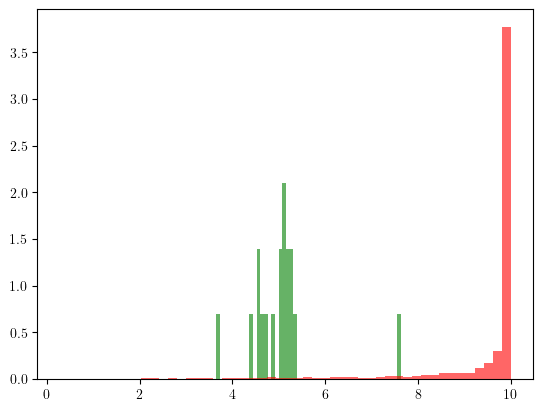

In [15]:
path_times_woc = f"path_times_WoC_2.json"
path_times_wohb = f"path_times_WoHB_2.json"
with open(path_times_woc, 'r') as json_file:
    # Use json.load() to convert the file content into a Python dictionary
    times_woc = json.load(json_file)
print(times_woc)
with open(path_times_wohb, 'r') as json_file:
    # Use json.load() to convert the file content into a Python dictionary
    times_wohb = json.load(json_file)
plt.hist(times_woc, bins=50, density=True, alpha=0.6, color='g');
plt.hist(times_wohb, bins=50, density=True, alpha=0.6, color='r');